In [6]:
from typing import Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from deepagents.backends import FilesystemBackend
from deepagents.middleware.filesystem import FilesystemMiddleware

load_dotenv()

DATA_DIR = "../examples-data"

model = ChatOpenAI(
    model="deepseek-v4-flash",
    model_kwargs={"extra_body": {"thinking": {"type": "disabled"}}},
    temperature=0.2,
)

/Users/zhengjie/Documents/learn-langgraph/.venv/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3687: UserWarning: Parameters {'extra_body'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


In [10]:
backend = FilesystemBackend(
    root_dir=DATA_DIR,
    virtual_mode=True,
)

SEARCH_MIDDLEWARE = FilesystemFileSearchMiddleware(
    root_path=str(DATA_DIR),
    use_ripgrep=True,
)
FS_TOOLS = ["ls", "read_file", "edit_file"]

EDITOR_SYSTEM_PROMPT = """
你是 Markdown 文档目录结构整理专家。修改文件只能使用 edit_file。

## 工具说明

* grep_search 支持正则表达式（基于 ripgrep）。
* 提取 Markdown 标题时，pattern 固定使用 `^#{1,6} `。
* 示例：
  `grep_search(pattern="^#{1,6} ", path=目标文件, output_mode="content")`
* 文件可能很大，默认不要读取全文。

## 工作流程

1. **提取标题**：使用 grep_search 提取全部 Markdown 标题及行号。
2. **判断结构**：优先根据标题编号、标题顺序、同级模式和现有层级判断正确结构。
3. **必要时读取**：只有无法仅根据标题列表判断时，才使用 read_file 查看相关位置附近的少量内容；不要连续读取正文。
4. **修改标题**：使用 edit_file 逐项修正，只修改标题行，不修改正文。
5. **复核**：修改完成后再次使用 grep_search 提取全部标题，确认层级合理且一致。

## 修改规则

* **最高层级**：真正的最高章节从 `#` 开始。
* **逐级递进**：子章节逐级增加一个 `#`，禁止无理由跳级，例如 `#` 直接到 `###`。
* **同级一致**：明显属于同一级别的章节应使用相同数量的 `#`。
* **综合判断**：有可靠 TOC 时可以参考；没有 TOC 或 TOC 不完整时，根据标题编号、标题规律和上下文判断。
* **不要盲从 MinerU**：原始 `#` 层级可能错误，只能作为参考。
* **非章节标题降级**：封面标题、字面为「目录」等明显不是正文章节的标题，不应作为一级章节；必要时可改为加粗。
* **格式清理**：去除标题中的无意义锚点，`#` 与标题文字之间保留一个半角空格。
* **最小修改**：只修正确认存在问题的标题，不改写标题文字，不修改正文。

不要主动扫描正文寻找可能遗漏的标题。

最终目标：使 Markdown 标题结构逻辑一致，并能够稳定按照一级标题 `# ` 拆分为完整章节。

如果收到 Auditor 反馈，只针对其指出的具体问题进行检查和修复，不要重新扫描整个文档。
"""

editor_agent = create_agent(
    model,
    system_prompt=EDITOR_SYSTEM_PROMPT,
    middleware=[
        FilesystemMiddleware(backend=backend, tools=FS_TOOLS),
        SEARCH_MIDDLEWARE,
    ],
)

AUDITOR_SYSTEM_PROMPT = """
你是 Markdown 文档结构审计员。

你只负责检查标题结构，不修改文件。

## 工具说明

* grep_search 支持正则表达式（基于 ripgrep）。
* 提取 Markdown 标题时，pattern 固定使用 `^#{1,6} `。
* 示例：
  `grep_search(pattern="^#{1,6} ", path=目标文件, output_mode="content")`
* 默认不要读取正文。

## 工作流程

1. 从当前 message 中确定目标 Markdown 文件。
2. 使用 grep_search 提取全部 Markdown 标题及行号。
3. 根据完整标题列表检查层级是否合理、一致。
4. 只有仅凭标题列表无法判断某个具体问题时，才使用 read_file 查看相关位置附近的少量内容。
5. 输出审计结果。

## 检查规则

* **最高层级**：真正的最高章节应从 `#` 开始。
* **逐级递进**：子章节应逐级增加一个 `#`，禁止无理由跳级，例如 `#` 直接到 `###`。
* **同级一致**：明显属于同一级别的章节应使用相同数量的 `#`。
* **编号一致**：如果存在 `1`、`1.1`、`1.1.1` 等明显编号关系，Markdown 层级应与其基本一致。
* **非章节标题**：封面标题、字面为「目录」等明显不是正文章节的内容，不应作为一级章节。
* **格式正确**：`#` 与标题文字之间应保留一个半角空格。
* **整体合理**：不要仅因为 Markdown 语法合法就判定通过，应检查完整标题结构是否逻辑一致。
* 不要求必须存在 TOC；存在可靠 TOC 时可作为辅助参考。

不要主动扫描正文寻找遗漏标题，也不要为了理解章节内容连续读取正文。

重点检查：一级标题 `# ` 是否能够作为稳定、合理的章节拆分边界。

## 输出

通过：简要说明检查结果，回复末尾必须包含 `[AUDIT_PASS]`

不通过：指出具体行号、当前问题以及建议的正确层级，回复末尾必须包含 `[AUDIT_FAIL]`
"""

auditor_agent = create_agent(
    model,
    system_prompt=AUDITOR_SYSTEM_PROMPT,
    middleware=[
        FilesystemMiddleware(backend=backend, tools=FS_TOOLS),
        SEARCH_MIDDLEWARE,
    ],
)


class AgentState(BaseModel):
    """工作流状态：messages 承载 Editor 对话；不接入 checkpointer，单次运行即起即止。"""

    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    is_valid: bool = False
    attempts: int = 0
    audit_feedback: str = ""


def auditor_node(state: AgentState) -> dict:
    """审计并评估：计数、审计、打回逻辑全部收敛在本节点内。"""
    attempts = state.attempts + 1

    original_request = state.messages[0].content
    audit_message = HumanMessage(
        content=(
            "请执行一次独立的 Markdown 结构审计。\n\n"
            f"原始任务（用于确定目标文件）：{original_request}\n\n"
            f"Editor 已完成第 {attempts} 次修改，请直接检查上述目标文件。"
        )
    )
    result = auditor_agent.invoke({"messages": [audit_message]})
    feedback = result["messages"][-1].content.strip()

    if "[AUDIT_PASS]" in feedback:
        return {"attempts": attempts, "is_valid": True, "audit_feedback": feedback}

    retry_message = HumanMessage(
        name="Auditor",
        content=(
            f"第 {attempts} 次修改未通过审计。\n\n"
            f"审计反馈：\n{feedback}\n\n"
            "请严格按照上面的具体行号和问题，使用工具修复目标 Markdown 文件。"
        ),
    )
    return {
        "attempts": attempts,
        "is_valid": False,
        "audit_feedback": feedback,
        "messages": [retry_message],
    }


def should_continue(state: AgentState) -> str:
    if state.is_valid:
        return END

    if state.attempts >= 3:
        return "fail"

    return "editor"


def fail_node(state: AgentState) -> dict:
    raise RuntimeError(
        f"经过 {state.attempts} 次修改仍未通过审计，流程终止。\n"
        f"最后一次反馈：\n{state.audit_feedback}"
    )


builder = StateGraph(AgentState)

builder.add_node("editor", editor_agent)
builder.add_node("auditor", auditor_node)
builder.add_node("fail", fail_node)

builder.add_edge(START, "editor")
builder.add_edge("editor", "auditor")

builder.add_conditional_edges(
    "auditor",
    should_continue,
    {
        "editor": "editor",
        "fail": "fail",
        END: END,
    },
)

graph = builder.compile()

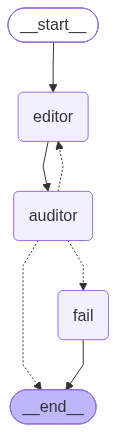

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
md_file = "油气管道地质灾害防护技术规范.md"
try:
    for chunk in workflow.stream(
            {"messages": [HumanMessage(content=f"请检查并修正 Markdown 文件 `{md_file}` 的标题层级结构。")]},
            stream_mode="values",
            version="v2",
            subgraphs=True
    ):
        ns = chunk.get("ns") or ()
        print(ns[0].split(":")[0] if ns else "root")
        message = chunk["data"].messages[-1]  # data 是 AgentState(pydantic)，不是 dict
        message.pretty_print()

except RuntimeError as e:
    print(f"\n💥 流程终止：{e}")

print("\n🎉 审计通过，流程结束。")

root
================================ Human Message =================================

请检查并修正 Markdown 文件 `油气管道地质灾害防护技术规范.md` 的标题层级结构。
editor
================================ Human Message =================================

请检查并修正 Markdown 文件 `油气管道地质灾害防护技术规范.md` 的标题层级结构。
editor
================================== Ai Message ==================================
Tool Calls:
  ls (call_00_4DdDhgO5HAfLksPxohHT4500)
 Call ID: call_00_4DdDhgO5HAfLksPxohHT4500
  Args:
    path: /
editor
================================= Tool Message =================================
Name: ls

['/.DS_Store', '/Chinook.db', '/layout-parser-paper.pdf', '/nke-10k-2023.pdf', '/油气管道地质灾害防护技术规范.md']
editor
================================== Ai Message ==================================
Tool Calls:
  grep_search (call_00_2bLeckHEn4dCQHGf6kP78186)
 Call ID: call_00_2bLeckHEn4dCQHGf6kP78186
  Args:
    pattern: ^#{1,6} 
    path: /油气管道地质灾害防护技术规范.md
    output_mode: content
editor
================================= Tool Mess